# Fall Detection — Engine-Compatible Training Pipeline
**Output:** `fall_detection_svm.pkl` (sklearn Pipeline) + `fall_detection_svm_config.json`

Pipeline ini langsung kompatibel dengan **MLInferenceEngine** tanpa wrapper:
- Model disimpan sebagai `sklearn Pipeline` → `predict_proba()` sudah ada
- `_config.json` di-generate otomatis dari kode — tidak perlu buat manual
- Fitur engine: `stat`, `derived (smv)`, `cross (corr)` — 44 fitur total

### Alur:
```
Dataset UMA ADL FALL
    → Load Chest Accelerometer (ax, ay, az)
    → Lowpass Filter (5 Hz)
    → Sliding Window (100 sampel, overlap 50%)
    → Feature Extraction (44 fitur)
    → sklearn Pipeline: StandardScaler → SMOTE → SVC RBF
    → Simpan .pkl + _config.json
```

## STEP 0 — Install & Import

In [13]:
!pip install scikit-learn imbalanced-learn scipy -q

import os, re, zipfile, pickle, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.signal import butter, filtfilt
from collections import Counter

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    StratifiedKFold, cross_validate,
    GridSearchCV, train_test_split
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, accuracy_score, f1_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

print('✅ Import OK')

✅ Import OK


## STEP 1 — Mount Google Drive & Extract Dataset

In [14]:
from google.colab import drive
import os
import shutil
import zipfile

# ── 1. Pembersihan & Mount Google Drive ──────────────────────────────────────
MOUNTPOINT = '/content/drive'

# Jika direktori ada dan tidak kosong, bersihkan terlebih dahulu untuk mencegah ValueError
if os.path.exists(MOUNTPOINT) and os.path.isdir(MOUNTPOINT) and os.listdir(MOUNTPOINT):
    print(f"⚠️ {MOUNTPOINT} tidak kosong. Membersihkan sisa file dari sesi sebelumnya...")
    try:
        shutil.rmtree(MOUNTPOINT)
    except Exception as e:
        print(f"Peringatan: Tidak bisa membersihkan folder secara otomatis. ({e})")

# Lakukan mount drive
drive.mount(MOUNTPOINT, force_remount=True)

# ── 2. Sesuaikan path dataset kamu ───────────────────────────────────────────
SOURCE_ZIP = '/content/drive/MyDrive/uma_fall_data/UMAFall_Dataset_corrected_version.zip'
DEST_ZIP   = 'UMA_ADL_FALL_Dataset.zip'
EXTRACT_DIR = '/content/UMA_Dataset'

# ── 3. Path output model & config ────────────────────────────────────────────
DRIVE_OUT_DIR = '/content/drive/MyDrive/uma_fall_data/output/'
os.makedirs(DRIVE_OUT_DIR, exist_ok=True)

MODEL_FILENAME  = 'fall_detection_svm.pkl'
CONFIG_FILENAME = 'fall_detection_svm_config.json'

# ── 4. Copy & Ekstrak Dataset ────────────────────────────────────────────────
print("\nMenyalin dataset ke runtime lokal...")
!cp "{SOURCE_ZIP}" "{DEST_ZIP}"
print(f'Dataset size: {os.path.getsize(DEST_ZIP)/1024/1024:.2f} MB')

print("Mengekstrak file zip utama...")
os.makedirs(EXTRACT_DIR, exist_ok=True)
with zipfile.ZipFile(DEST_ZIP, 'r') as z:
    z.extractall(EXTRACT_DIR)

# Extract nested zips (zip di dalam zip)
print("Mengekstrak zip tambahan di dalam folder (jika ada)...")
changed = True
while changed:
    changed = False
    for root, dirs, files in os.walk(EXTRACT_DIR):
        for f in files:
            if f.endswith('.zip'):
                zp = os.path.join(root, f)
                out = zp.replace('.zip', '')
                os.makedirs(out, exist_ok=True)
                with zipfile.ZipFile(zp, 'r') as z2:
                    z2.extractall(out)
                os.remove(zp)  # Hapus file zip setelah diekstrak agar hemat ruang
                changed = True

# ── 5. Kumpulkan semua file CSV ──────────────────────────────────────────────
all_csv = []
for root, dirs, files in os.walk(EXTRACT_DIR):
    for f in files:
        if f.lower().endswith('.csv'):
            all_csv.append(os.path.join(root, f))

print(f'\n✅ Ekstraksi selesai — {len(all_csv)} file CSV ditemukan')

⚠️ /content/drive tidak kosong. Membersihkan sisa file dari sesi sebelumnya...
Peringatan: Tidak bisa membersihkan folder secara otomatis. ([Errno 125] Operation canceled: '/content/drive/.Encrypted/.shortcut-targets-by-id')
Mounted at /content/drive

Menyalin dataset ke runtime lokal...
Dataset size: 74.85 MB
Mengekstrak file zip utama...
Mengekstrak zip tambahan di dalam folder (jika ada)...

✅ Ekstraksi selesai — 746 file CSV ditemukan


## STEP 2 — Konfigurasi

Semua parameter ada di sini. Ubah sesuai kebutuhan — config JSON akan di-generate otomatis dari sini.

In [15]:
# ── Sensor settings ──────────────────────────────────────────────────────────
CHEST_ID    = 1
ACCEL_T     = 0
FS          = 20      # Hz
WINDOW_SIZE = 64      # ⚠ Engine menggunakan CS_N=64 — sesuaikan di sini
STEP_SIZE   = 32      # 50% overlap

# ── Label mapping ─────────────────────────────────────────────────────────────
# PENTING: urutan ini menentukan urutan di "labels" config JSON
# Urutan HARUS SAMA dengan model.classes_ nanti (sklearn sort alphabetically)
# Kelas kita: duduk, jalan, jatuh, tidur → sorted: ['duduk','jalan','jatuh','tidur']
LABEL_MAP = [
    ('fall_backwardfall',  'jatuh'),
    ('fall_forwardfall',   'jatuh'),
    ('fall_lateralfall',   'jatuh'),
    ('adl_sitting',        'duduk'),
    ('adl_lyingdown',      'tidur'),
    ('adl_walking',        'jalan'),
    ('adl_jogging',        'jalan'),
    ('adl_goupstairs',     'jalan'),
    ('adl_godownstairs',   'jalan'),
    ('adl_hopping',        None),
    ('adl_bending',        None),
    ('adl_aplausing',      None),
    ('adl_handsup',        None),
    ('adl_makingacall',    None),
    ('adl_openingdoor',    None),
]

# ── Model metadata (untuk _config.json) ──────────────────────────────────────
MODEL_NAME    = 'fall_detection_svm_v1'
MODEL_VERSION = '1.0.0'
AUTHOR        = 'imu-team'

# ── Engine output config ─────────────────────────────────────────────────────
CONFIDENCE_THRESHOLD = 0.30   # di bawah ini → label "uncertain"

print('✅ Konfigurasi OK')
print(f'   Window size : {WINDOW_SIZE} sampel = {WINDOW_SIZE/FS:.1f}s @ {FS}Hz')
print(f'   Step size   : {STEP_SIZE} sampel')

✅ Konfigurasi OK
   Window size : 64 sampel = 3.2s @ 20Hz
   Step size   : 32 sampel


## STEP 3 — Load Data & Filter

In [16]:
def get_label(filepath):
    fname = os.path.basename(filepath).lower()
    for keyword, label in LABEL_MAP:
        if keyword in fname:
            return label
    return None

def read_chest(fp):
    try:
        df = pd.read_csv(
            fp, sep=';', comment='%', header=None,
            names=['ts','sn','x','y','z','stype','sid'],
            skipinitialspace=True, on_bad_lines='skip'
        )
        df = df.apply(pd.to_numeric, errors='coerce').dropna()
        chest = df[(df['sid']==CHEST_ID) & (df['stype']==ACCEL_T)][['x','y','z']]
        chest = chest.dropna()
        if len(chest) < WINDOW_SIZE:
            return None
        return chest.values.astype(np.float32)
    except:
        return None

def lowpass(sig, cutoff=5.0, fs=20.0, order=4):
    b, a = butter(order, cutoff/(0.5*fs), btype='low')
    return filtfilt(b, a, sig)

records = []
n_skipped = 0
for fp in all_csv:
    lbl = get_label(fp)
    if lbl is None:
        n_skipped += 1
        continue
    data = read_chest(fp)
    if data is None:
        n_skipped += 1
        continue
    data_filt = np.column_stack([lowpass(data[:,i]) for i in range(3)])
    records.append((data_filt, lbl))

print(f'✅ Berhasil : {len(records)} file')
print(f'   Dilewati : {n_skipped} file')
print()
for k, v in sorted(Counter(r[1] for r in records).items()):
    print(f'   {k}: {v} file')

✅ Berhasil : 460 file
   Dilewati : 286 file

   duduk: 64 file
   jalan: 131 file
   jatuh: 208 file
   tidur: 57 file


## STEP 4 — Sliding Window & Feature Extraction

In [17]:
# ── Feature schema (SSOT — dipakai untuk training DAN generate config JSON) ──
#
# Setiap entry adalah tuple:
#   (feat_name, config_entry_dict)
#
# feat_name    → nama kolom, hanya untuk referensi
# config_entry → dict yang nanti masuk ke "features" di _config.json
#
# URUTAN DI SINI = URUTAN FITUR SAAT TRAINING = URUTAN DI CONFIG JSON
# Jangan ubah urutan setelah model di-train!

FEATURE_SCHEMA = []

# 30 fitur per-axis (ax, ay, az)
for sig in ['ax', 'ay', 'az']:
    for stat, cfg_stat in [
        ('mean',  'mean'),
        ('std',   'std'),
        ('min',   'min'),
        ('max',   'max'),
        ('range', 'range'),
        ('skew',  'skew'),
        ('kurt',  'kurt'),
        ('rms',   'rms'),
        ('q1',    'p25'),
        ('q3',    'p75'),
    ]:
        FEATURE_SCHEMA.append((
            f'{sig}_{stat}',
            {"name": f'{sig}_{stat}', "type": "stat", "signal": sig, "stat": cfg_stat}
        ))

# 8 fitur SMV
for stat, cfg_stat in [
    ('mean',  'mean'), ('std',  'std'), ('max',  'max'), ('min',  'min'),
    ('range', 'range'), ('skew', 'skew'), ('kurt', 'kurt'), ('rms',  'rms'),
]:
    FEATURE_SCHEMA.append((
        f'smv_{stat}',
        {"name": f'smv_{stat}', "type": "derived", "formula": "smv", "stat": cfg_stat}
    ))

# 3 fitur ZCR per axis
for sig in ['ax', 'ay', 'az']:
    FEATURE_SCHEMA.append((
        f'{sig}_zcr',
        {"name": f'{sig}_zcr', "type": "stat", "signal": sig, "stat": "zcr"}
    ))

# 3 fitur korelasi
for (sa, sb, name) in [('ax','ay','corr_xy'), ('ax','az','corr_xz'), ('ay','az','corr_yz')]:
    FEATURE_SCHEMA.append((
        name,
        {"name": name, "type": "cross", "signal_a": sa, "signal_b": sb,
         "cross_type": "corr", "default": 0.0}
    ))

N_FEATURES = len(FEATURE_SCHEMA)
print(f'Total fitur : {N_FEATURES}')
print()

# Tampilkan schema
print(f'  {"#":>3}  {"Nama Fitur":20s}  {"Type":8s}  Detail')
print('  ' + '-'*60)
for i, (name, cfg) in enumerate(FEATURE_SCHEMA):
    if cfg['type'] == 'stat':
        detail = f'signal={cfg["signal"]}, stat={cfg["stat"]}'
    elif cfg['type'] == 'derived':
        detail = f'formula={cfg["formula"]}, stat={cfg["stat"]}'
    elif cfg['type'] == 'cross':
        detail = f'{cfg["signal_a"]} × {cfg["signal_b"]}, {cfg["cross_type"]}'
    else:
        detail = ''
    print(f'  {i:>3}  {name:20s}  {cfg["type"]:8s}  {detail}')

Total fitur : 44

    #  Nama Fitur            Type      Detail
  ------------------------------------------------------------
    0  ax_mean               stat      signal=ax, stat=mean
    1  ax_std                stat      signal=ax, stat=std
    2  ax_min                stat      signal=ax, stat=min
    3  ax_max                stat      signal=ax, stat=max
    4  ax_range              stat      signal=ax, stat=range
    5  ax_skew               stat      signal=ax, stat=skew
    6  ax_kurt               stat      signal=ax, stat=kurt
    7  ax_rms                stat      signal=ax, stat=rms
    8  ax_q1                 stat      signal=ax, stat=p25
    9  ax_q3                 stat      signal=ax, stat=p75
   10  ay_mean               stat      signal=ay, stat=mean
   11  ay_std                stat      signal=ay, stat=std
   12  ay_min                stat      signal=ay, stat=min
   13  ay_max                stat      signal=ay, stat=max
   14  ay_range              stat      si

In [18]:
def extract_features(win):
    """
    Ekstrak 44 fitur dari window shape (WINDOW_SIZE, 3).
    URUTAN HARUS SAMA dengan FEATURE_SCHEMA di atas.
    """
    ax, ay, az = win[:,0], win[:,1], win[:,2]
    smv = np.sqrt(ax**2 + ay**2 + az**2)
    feats = []

    # ── 30 fitur per-axis ─────────────────────────────────────────────────────
    for a in [ax, ay, az]:
        feats += [
            np.mean(a),
            np.std(a),
            np.min(a),
            np.max(a),
            float(np.max(a) - np.min(a)),           # range
            float(stats.skew(a)),
            float(stats.kurtosis(a)),               # Fisher (excess)
            float(np.sqrt(np.mean(a**2))),          # rms
            float(np.percentile(a, 25)),            # q1
            float(np.percentile(a, 75)),            # q3
        ]

    # ── 8 fitur SMV ───────────────────────────────────────────────────────────
    feats += [
        np.mean(smv),
        np.std(smv),
        np.max(smv),
        np.min(smv),
        float(np.max(smv) - np.min(smv)),
        float(stats.skew(smv)),
        float(stats.kurtosis(smv)),
        float(np.sqrt(np.mean(smv**2))),
    ]

    # ── 3 ZCR per axis ────────────────────────────────────────────────────────
    for a in [ax, ay, az]:
        feats.append(float(np.sum(np.diff(np.sign(a)) != 0) / len(a)))

    # ── 3 Korelasi ────────────────────────────────────────────────────────────
    feats.append(float(np.corrcoef(ax, ay)[0,1]))
    feats.append(float(np.corrcoef(ax, az)[0,1]))
    feats.append(float(np.corrcoef(ay, az)[0,1]))

    return np.array(feats, dtype=np.float64)

# ── Sliding window + feature extraction ──────────────────────────────────────
X_list, y_list = [], []
for data, lbl in records:
    for start in range(0, len(data) - WINDOW_SIZE + 1, STEP_SIZE):
        win = data[start : start + WINDOW_SIZE]
        X_list.append(extract_features(win))
        y_list.append(lbl)

X = np.array(X_list, dtype=np.float64)
y_raw = np.array(y_list)

# Encode label (sklearn sort alphabetically → ['duduk','jalan','jatuh','tidur'])
le = LabelEncoder()
y = le.fit_transform(y_raw)
CLASSES = list(le.classes_)

# Bersihkan NaN/Inf
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

win_dist  = Counter(y_raw)
total_win = len(y_raw)

print(f'✅ Feature extraction selesai')
print(f'   X shape    : {X.shape}')
print(f'   Kelas      : {CLASSES}')
print()
print(f'  {"Label":10s}  {"Count":>6s}  {"Pct":>6s}  Bar')
print('  ' + '-'*45)
for lbl, cnt in sorted(win_dist.items()):
    pct = 100*cnt/total_win
    bar = chr(9608)*int(pct/2)
    print(f'  {lbl:10s}  {cnt:6d}  {pct:5.1f}%  {bar}')
vals = list(win_dist.values())
ratio = max(vals)/min(vals)
print(f'\n  Rasio imbalance: {ratio:.1f}x')

✅ Feature extraction selesai
   X shape    : (3628, 44)
   Kelas      : [np.str_('duduk'), np.str_('jalan'), np.str_('jatuh'), np.str_('tidur')]

  Label        Count     Pct  Bar
  ---------------------------------------------
  duduk          504   13.9%  ██████
  jalan         1027   28.3%  ██████████████
  jatuh         1649   45.5%  ██████████████████████
  tidur          448   12.3%  ██████

  Rasio imbalance: 3.7x


## STEP 5 — Visualisasi Distribusi & Sinyal

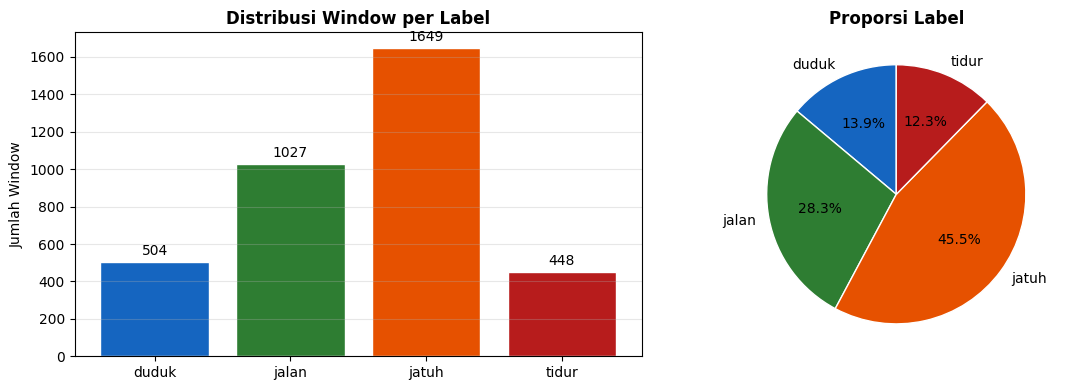

In [19]:
labels_s = sorted(win_dist.keys())
counts_s = [win_dist[l] for l in labels_s]
colors4  = ['#1565C0', '#2E7D32', '#E65100', '#B71C1C']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
bars = ax1.bar(labels_s, counts_s, color=colors4[:len(labels_s)], edgecolor='white')
ax1.bar_label(bars, padding=3)
ax1.set_title('Distribusi Window per Label', fontweight='bold')
ax1.set_ylabel('Jumlah Window')
ax1.grid(axis='y', alpha=0.3)
ax2.pie(counts_s, labels=labels_s, autopct='%1.1f%%',
        colors=colors4[:len(labels_s)], startangle=90,
        wedgeprops={'edgecolor':'white'})
ax2.set_title('Proporsi Label', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/distribusi_label.png', dpi=130)
plt.show()

## STEP 6 — Train/Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} window')
print(f'Test : {X_test.shape[0]} window')
print()
print('Distribusi train:')
for i, cls in enumerate(CLASSES):
    print(f'  {cls}: {np.sum(y_train==i)}')

Train: 2902 window
Test : 726 window

Distribusi train:
  duduk: 403
  jalan: 822
  jatuh: 1319
  tidur: 358


## STEP 7 — Training Pipeline

Pipeline: **StandardScaler → SMOTE → SVC RBF**

Model disimpan sebagai `sklearn Pipeline` langsung — compatible dengan engine tanpa wrapper.

In [21]:
# ── Baseline CV ──────────────────────────────────────────────────────────────
baseline_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(random_state=42, k_neighbors=3)),
    ('svm',    SVC(kernel='rbf', C=1.0, gamma='scale',
                   class_weight='balanced', random_state=42, probability=True))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print('Menjalankan Baseline CV (5-fold)...')
baseline_cv = cross_validate(
    baseline_pipe, X_train, y_train, cv=cv,
    scoring=['accuracy', 'f1_macro'], n_jobs=-1
)
print(f'  Accuracy  : {baseline_cv["test_accuracy"].mean():.4f} ± {baseline_cv["test_accuracy"].std():.4f}')
print(f'  F1 Macro  : {baseline_cv["test_f1_macro"].mean():.4f} ± {baseline_cv["test_f1_macro"].std():.4f}')

Menjalankan Baseline CV (5-fold)...
  Accuracy  : 0.8722 ± 0.0152
  F1 Macro  : 0.8237 ± 0.0197


In [31]:
# ── GridSearchCV ─────────────────────────────────────────────────────────────
param_grid = {
    'svm__C'    : [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.01, 0.001],
}
tune_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(random_state=42, k_neighbors=3)),
    # ('svm',    SVC(kernel='rbf', class_weight='balanced', random_state=42, probability=True))
    ('svm',    SVC(kernel='rbf', random_state=42, probability=True))
])
grid_search = GridSearchCV(
    tune_pipe, param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro', n_jobs=-1, verbose=1
)
print('Menjalankan GridSearchCV (4×4×5 = 80 fits)...')
grid_search.fit(X_train, y_train)
print(f'\nBest params    : {grid_search.best_params_}')
print(f'Best F1 (CV)   : {grid_search.best_score_:.4f}')

Menjalankan GridSearchCV (4×4×5 = 80 fits)...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best params    : {'svm__C': 1, 'svm__gamma': 'scale'}
Best F1 (CV)   : 0.8237


## STEP 8 — Evaluasi Test Set

In [32]:
best_model = grid_search.best_estimator_   # ImbPipeline

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
f1m = f1_score(y_test, y_pred, average='macro')
f1w = f1_score(y_test, y_pred, average='weighted')

print('='*56)
print('       HASIL EVALUASI — TEST SET (20%)')
print('='*56)
print()
print(classification_report(y_test, y_pred, target_names=CLASSES, digits=4))
print(f'Accuracy   : {acc:.4f} ({acc*100:.2f}%)')
print(f'F1 Macro   : {f1m:.4f}')
print(f'F1 Weighted: {f1w:.4f}')

try:
    auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
    print(f'AUC OvR    : {auc:.4f}')
except Exception as e:
    print(f'AUC: {e}')

       HASIL EVALUASI — TEST SET (20%)

              precision    recall  f1-score   support

       duduk     0.5658    0.8515    0.6798       101
       jalan     0.9721    0.8488    0.9062       205
       jatuh     0.9691    0.9515    0.9602       330
       tidur     0.8310    0.6556    0.7329        90

    accuracy                         0.8719       726
   macro avg     0.8345    0.8268    0.8198       726
weighted avg     0.8967    0.8719    0.8778       726

Accuracy   : 0.8719 (87.19%)
F1 Macro   : 0.8198
F1 Weighted: 0.8778
AUC OvR    : 0.9712


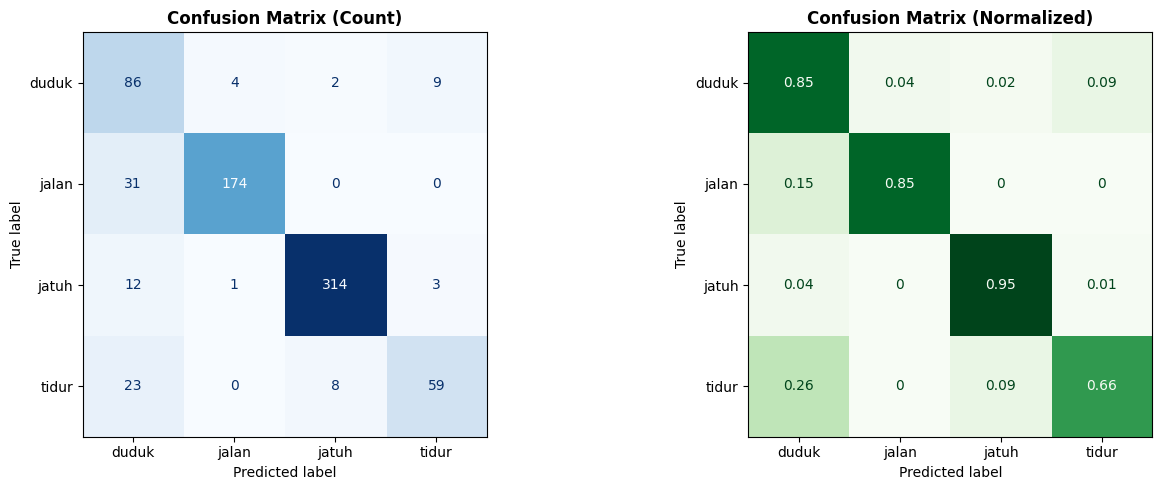

In [33]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm      = confusion_matrix(y_test, y_pred)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')

ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (Count)', fontweight='bold')

ConfusionMatrixDisplay(np.round(cm_norm,2), display_labels=CLASSES).plot(
    ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=130)
plt.show()

## STEP 9 — Verifikasi Engine Compatibility

Cek bahwa model sudah memenuhi semua kontrak engine sebelum disimpan.

In [34]:
print('── Verifikasi Engine Compatibility ─────────────────────────')
print()

# 1. predict_proba ada?
assert hasattr(best_model, 'predict_proba'), '✗ predict_proba tidak ada!'
print('✓ predict_proba() tersedia')

# 2. Output shape benar?
X_dummy = np.random.randn(5, N_FEATURES)
proba   = best_model.predict_proba(X_dummy)
assert proba.shape == (5, len(CLASSES)), f'✗ Shape salah: {proba.shape}'
print(f'✓ predict_proba output shape: {proba.shape}  (n_samples, n_classes)')

# 3. Probabilitas sum ke 1?
assert np.allclose(proba.sum(axis=1), 1.0, atol=1e-5), '✗ Proba tidak sum ke 1!'
print(f'✓ Probabilitas sum ≈ 1.0  {proba.sum(axis=1).tolist()}')

# 4. n_features_in_ ada?
if hasattr(best_model, 'n_features_in_'):
    print(f'✓ n_features_in_ = {best_model.n_features_in_}')
else:
    print('⚠ n_features_in_ tidak ada (validasi engine akan dilewati)')

# 5. Urutan classes_ konsisten?
svc_step = best_model.named_steps['svm']
# Ambil nilai integer dari kelas SVC
svc_classes = [int(c) for c in svc_step.classes_]
print(f'✓ SVC classes_  : {svc_classes}')
print(f'✓ LabelEncoder  : {CLASSES}')

# SVC classes seharusnya berisi angka 0 sampai len(CLASSES)-1
expected_classes = list(range(len(CLASSES)))

assert svc_classes == expected_classes, (
    f'✗ MISMATCH! SVC={svc_classes}, Expected={expected_classes}\n'
    'Pastikan LabelEncoder dan SVC difit dengan data yang sama.'
)
print('✓ Urutan kelas konsisten (Index numerik cocok)')

# 6. Jumlah fitur = jumlah schema?
assert N_FEATURES == len(FEATURE_SCHEMA), f'✗ Fitur mismatch: {N_FEATURES} vs {len(FEATURE_SCHEMA)}'
print(f'✓ Jumlah fitur  : {N_FEATURES} (config) = {N_FEATURES} (training)')

print()
print('✅ Semua cek passed — model siap disimpan')

── Verifikasi Engine Compatibility ─────────────────────────

✓ predict_proba() tersedia
✓ predict_proba output shape: (5, 4)  (n_samples, n_classes)
✓ Probabilitas sum ≈ 1.0  [1.0000000000000004, 0.9999999999999997, 0.9999999999999997, 1.0, 1.0]
✓ n_features_in_ = 44
✓ SVC classes_  : [0, 1, 2, 3]
✓ LabelEncoder  : [np.str_('duduk'), np.str_('jalan'), np.str_('jatuh'), np.str_('tidur')]
✓ Urutan kelas konsisten (Index numerik cocok)
✓ Jumlah fitur  : 44 (config) = 44 (training)

✅ Semua cek passed — model siap disimpan


## STEP 10 — Simpan Model & Auto-Generate Config JSON

Model disimpan langsung sebagai `sklearn Pipeline` — tidak perlu wrapper.
Config JSON di-generate otomatis dari `FEATURE_SCHEMA` yang sama dengan training.

In [35]:
import datetime

# ─────────────────────────────────────────────────────────────────────────────
# A. Simpan model .pkl  (langsung Pipeline, bukan dict)
# ─────────────────────────────────────────────────────────────────────────────
MODEL_PATH  = f'/content/{MODEL_FILENAME}'
pickle.dump(best_model, open(MODEL_PATH, 'wb'), protocol=4)

size_kb = os.path.getsize(MODEL_PATH) / 1024
print(f'✅ Model tersimpan : {MODEL_PATH}  ({size_kb:.1f} KB)')
print(f'   Type            : {type(best_model).__name__}')
print(f'   Steps           : {[s[0] for s in best_model.steps]}')

# ─────────────────────────────────────────────────────────────────────────────
# B. Generate _config.json dari FEATURE_SCHEMA (SSOT)
# ─────────────────────────────────────────────────────────────────────────────
config = {
    "model_name"    : MODEL_NAME,
    "model_version" : MODEL_VERSION,
    "description"   : (
        f"Fall detection 4-class (duduk/jalan/jatuh/tidur) — SVM RBF, "
        f"trained on UMA ADL FALL dataset, Chest Accelerometer, "
        f"window={WINDOW_SIZE}s@{FS}Hz"
    ),
    "author"        : AUTHOR,
    "trained_at"    : datetime.datetime.now().strftime('%Y-%m'),

    "labels"        : CLASSES,   # urutan dari LabelEncoder (alphabetical)

    "features"      : [cfg for _, cfg in FEATURE_SCHEMA],  # 44 fitur, urutan sama

    "skip_if": {
        "require_signals": ["ax", "ay", "az"]
    },

    "output": {
        "confidence_threshold": CONFIDENCE_THRESHOLD
    },

    # Metadata tambahan (informatif, tidak dibaca engine)
    "_training_info": {
        "window_size"  : WINDOW_SIZE,
        "step_size"    : STEP_SIZE,
        "fs_hz"        : FS,
        "n_features"   : N_FEATURES,
        "best_params"  : grid_search.best_params_,
        "best_cv_f1"   : round(grid_search.best_score_, 4),
        "test_accuracy": round(acc, 4),
        "test_f1_macro": round(f1m, 4),
        "n_train"      : int(X_train.shape[0]),
        "n_test"       : int(X_test.shape[0]),
    }
}

CONFIG_PATH = f'/content/{CONFIG_FILENAME}'
with open(CONFIG_PATH, 'w') as f:
    json.dump(config, f, indent=4, ensure_ascii=False)

print(f'\n✅ Config tersimpan: {CONFIG_PATH}')
print(f'   Labels   : {config["labels"]}')
print(f'   N fitur  : {len(config["features"])}')

# Tampilkan isi config
print()
print('── Isi _config.json ────────────────────────────────────────')
print(json.dumps({k:v for k,v in config.items() if k != '_training_info'}, indent=2, ensure_ascii=False))

✅ Model tersimpan : /content/fall_detection_svm.pkl  (924.3 KB)
   Type            : Pipeline
   Steps           : ['scaler', 'smote', 'svm']

✅ Config tersimpan: /content/fall_detection_svm_config.json
   Labels   : [np.str_('duduk'), np.str_('jalan'), np.str_('jatuh'), np.str_('tidur')]
   N fitur  : 44

── Isi _config.json ────────────────────────────────────────
{
  "model_name": "fall_detection_svm_v1",
  "model_version": "1.0.0",
  "description": "Fall detection 4-class (duduk/jalan/jatuh/tidur) — SVM RBF, trained on UMA ADL FALL dataset, Chest Accelerometer, window=64s@20Hz",
  "author": "imu-team",
  "trained_at": "2026-05",
  "labels": [
    "duduk",
    "jalan",
    "jatuh",
    "tidur"
  ],
  "features": [
    {
      "name": "ax_mean",
      "type": "stat",
      "signal": "ax",
      "stat": "mean"
    },
    {
      "name": "ax_std",
      "type": "stat",
      "signal": "ax",
      "stat": "std"
    },
    {
      "name": "ax_min",
      "type": "stat",
      "signal": "

In [36]:
# ─────────────────────────────────────────────────────────────────────────────
# C. Copy ke Google Drive
# ─────────────────────────────────────────────────────────────────────────────
import shutil

for fname in [MODEL_FILENAME, CONFIG_FILENAME, 'confusion_matrix.png', 'distribusi_label.png']:
    src = f'/content/{fname}'
    dst = os.path.join(DRIVE_OUT_DIR, fname)
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f'✅ Copied: {fname} → {DRIVE_OUT_DIR}')

print()
print('── Langkah Deploy ke Engine ────────────────────────────────')
print(f'  1. Copy {MODEL_FILENAME} ke  server/apps/ml_inference/models/imu/')
print(f'  2. Copy {CONFIG_FILENAME} ke server/apps/ml_inference/models/imu/')
print(f'  3. Jalankan: registry.scan("models/", recursive=True)')
print(f'  4. Cek     : registry.status() → loaded=True')
print()
print('── Tidak perlu wrapper! Model langsung sklearn Pipeline ────')

✅ Copied: fall_detection_svm.pkl → /content/drive/MyDrive/uma_fall_data/output/
✅ Copied: fall_detection_svm_config.json → /content/drive/MyDrive/uma_fall_data/output/
✅ Copied: confusion_matrix.png → /content/drive/MyDrive/uma_fall_data/output/
✅ Copied: distribusi_label.png → /content/drive/MyDrive/uma_fall_data/output/

── Langkah Deploy ke Engine ────────────────────────────────
  1. Copy fall_detection_svm.pkl ke  server/apps/ml_inference/models/imu/
  2. Copy fall_detection_svm_config.json ke server/apps/ml_inference/models/imu/
  3. Jalankan: registry.scan("models/", recursive=True)
  4. Cek     : registry.status() → loaded=True

── Tidak perlu wrapper! Model langsung sklearn Pipeline ────


## STEP 11 — Smoke Test (Simulasi Inferensi Engine)

In [37]:
# Simulasi persis seperti yang dilakukan MLInferenceEngine
# Input: 1 window feature vector, dtype float64

print('── Smoke Test — Simulasi Inferensi Engine ──────────────────')
print()

# Load ulang dari disk (pastikan pkl bisa di-load kembali)
model_loaded = pickle.load(open(MODEL_PATH, 'rb'))

# Buat X dummy
X_sim = X_test[:3].astype(np.float64)   # 3 sample dari test set

proba  = model_loaded.predict_proba(X_sim)
labels = model_loaded.predict(X_sim)

print(f'Input shape   : {X_sim.shape}')
print(f'Output shape  : {proba.shape}')
print()
print(f'  {"Sample":>8}  {"Prediksi":10s}  {"Confidence":>12s}  Probabilitas')
print('  ' + '-'*65)
for i in range(len(X_sim)):
    pred_idx   = labels[i]
    pred_label = CLASSES[pred_idx]
    confidence = proba[i].max()
    proba_str  = '  '.join([f'{CLASSES[j]}:{proba[i,j]:.3f}' for j in range(len(CLASSES))])
    print(f'  {i:>8}  {pred_label:10s}  {confidence:>12.3f}  {proba_str}')

print()
print(f'classes_ dari pipeline : {list(model_loaded.named_steps["svm"].classes_)}')
print(f'n_features_in_         : {model_loaded.n_features_in_ if hasattr(model_loaded, "n_features_in_") else "N/A"}')
print()
print('✅ Smoke test selesai — model siap digunakan engine')

── Smoke Test — Simulasi Inferensi Engine ──────────────────

Input shape   : (3, 44)
Output shape  : (3, 4)

    Sample  Prediksi      Confidence  Probabilitas
  -----------------------------------------------------------------
         0  jalan              0.966  duduk:0.003  jalan:0.966  jatuh:0.020  tidur:0.012
         1  duduk              0.740  duduk:0.740  jalan:0.020  jatuh:0.039  tidur:0.201
         2  jalan              0.990  duduk:0.003  jalan:0.990  jatuh:0.004  tidur:0.003

classes_ dari pipeline : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
n_features_in_         : 44

✅ Smoke test selesai — model siap digunakan engine


## STEP 12 — Laporan Akhir


In [38]:
print('='*60)
print('              LAPORAN MODEL FINAL')
print('='*60)
print(f'  Algoritma         : SVM (RBF kernel)')
print(f'  Best C            : {grid_search.best_params_["svm__C"]}')
print(f'  Best gamma        : {grid_search.best_params_["svm__gamma"]}')
print(f'  Scaler            : StandardScaler (dalam pipeline)')
print(f'  Imbalance handler : SMOTE + class_weight=balanced')
print(f'  Validasi          : StratifiedKFold-5')
print(f'  Window size       : {WINDOW_SIZE} sampel = {WINDOW_SIZE/FS:.1f}s @ {FS}Hz')
print()
print(f'  ── Test Set Results ──')
print(f'  Accuracy          : {acc:.4f} ({acc*100:.2f}%)')
print(f'  F1 Macro          : {f1m:.4f}')
print(f'  F1 Weighted       : {f1w:.4f}')
print()
print(f'  ── Engine Compatibility ──')
print(f'  Format            : sklearn Pipeline (TIDAK perlu wrapper)')
print(f'  predict_proba()   : ✓')
print(f'  n_features_in_    : {getattr(best_model, "n_features_in_", "N/A")}')
print(f'  Kelas             : {CLASSES}')
print(f'  Jumlah fitur      : {N_FEATURES}')
print(f'  Config JSON       : {CONFIG_FILENAME} (auto-generated)')
print('='*60)

              LAPORAN MODEL FINAL
  Algoritma         : SVM (RBF kernel)
  Best C            : 1
  Best gamma        : scale
  Scaler            : StandardScaler (dalam pipeline)
  Imbalance handler : SMOTE + class_weight=balanced
  Validasi          : StratifiedKFold-5
  Window size       : 64 sampel = 3.2s @ 20Hz

  ── Test Set Results ──
  Accuracy          : 0.8719 (87.19%)
  F1 Macro          : 0.8198
  F1 Weighted       : 0.8778

  ── Engine Compatibility ──
  Format            : sklearn Pipeline (TIDAK perlu wrapper)
  predict_proba()   : ✓
  n_features_in_    : 44
  Kelas             : [np.str_('duduk'), np.str_('jalan'), np.str_('jatuh'), np.str_('tidur')]
  Jumlah fitur      : 44
  Config JSON       : fall_detection_svm_config.json (auto-generated)
